## Análisis de Generalización de Modelos de Clasificación de Emociones mediante Validación Externa.

Para evaluar la capacidad de generalización de los modelos entrenados, se realiza una validación externa utilizando el dataset CK+.  
Al ser un conjunto de datos que los modelos no han visto durante el entrenamiento y que posee condiciones de iluminación y sujetos diferentes, sirve como métrica de robustez frente al fenómeno de desplazamiento de domino (Domain Shift).

### Librerías

In [1]:
import sys

if 'google.colab' in sys.modules:
    print("Entorno Colab detectado. Asegurando instalación de librerias...")
    !pip install -q torchinfo ultralytics

import os
import gdown
import shutil
import random
import zipfile

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
from torch.utils.data import Dataset
import torchvision.transforms as T
from torchinfo import summary

import cv2
from ultralytics import YOLO
from huggingface_hub import hf_hub_download

from transformers import AutoModelForImageClassification
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm 

### Descarga y procesamiento del dataset
El dataset CK+ es uno de los bancos de pruebas más utilizados para el desarrollo y la evaluación de algoritmos de reconocimiento de expresiones faciales automáticas (FER).  
A diferencia de otros datasets recolectados "en la naturaleza" (como FER2013), CK+ se caracteriza por ser un entorno controlado, lo que permite una validación muy precisa de las unidades de acción facial.  
Se trabaja con una version preprocedada que solamente incluye las secuencias de videos (frames) y sus etiquetas.
#### Características principales
* **Contenido**: Incluye 593 secuencias de video de 123 sujetos distintos.
* **Etiquetado**: Las expresiones están codificadas según el sistema FACS (Facial Action Coding System) y validadas en las 7 emociones básicas:
    * Ira (Anger)
    * Desprecio (Contempt)
    * Asco (Disgust)
    * Miedo (Fear)
    * Felicidad (Happiness) 
    * Tristeza (Sadness)
    * Sorpresa (Surprise)
* **Dinámica**: Las secuencias van desde una expresión neutra hasta el "pico" de la emoción, lo cual es ideal para probar qué tan sensible es tu modelo a diferentes intensidades.
* **Página Oficial** (Carnegie Mellon University): [The Robotics Institute - CK+ Database](https://www.ri.cmu.edu/project/cohn-kanade-au-coded-facial-expression-database/)

In [2]:
# Rutas y URL
url = "https://drive.google.com/uc?id=1V-o936ispK-kHouNSKQLWh02y6eLuiu6"
carpeta_base = "datasets"
subcarpeta_destino = os.path.join(carpeta_base, "CKplus")
archivo_zip = os.path.join(carpeta_base, "CKPlusdataset.zip")

# Verifica si la subcarpeta de destino ya existe
if os.path.exists(subcarpeta_destino):
    print(f"✅ El dataset ya se encuentra en '{subcarpeta_destino}'. No es necesario descargar.")
else:
    # Si no existe, procede con la descarga y extracción
    print("🚀 El dataset no fue encontrado. Iniciando descarga...")
    
    # Crea carpeta base si no existe
    os.makedirs(carpeta_base, exist_ok=True)

    # Descarga
    gdown.download(url, archivo_zip, quiet=False)

    # Descomprime
    print(f"📦 Descomprimiendo en: {subcarpeta_destino}...")
    os.makedirs(subcarpeta_destino, exist_ok=True)
    with zipfile.ZipFile(archivo_zip, 'r') as zip_ref:
        zip_ref.extractall(subcarpeta_destino)

    # Elimina el archivo ZIP original
    if os.path.exists(archivo_zip):
        os.remove(archivo_zip)
        print("🧹 Archivo ZIP temporal eliminado.")

    print("✨ Proceso de instalación finalizado.")

🚀 El dataset no fue encontrado. Iniciando descarga...


Downloading...
From (original): https://drive.google.com/uc?id=1V-o936ispK-kHouNSKQLWh02y6eLuiu6
From (redirected): https://drive.google.com/uc?id=1V-o936ispK-kHouNSKQLWh02y6eLuiu6&confirm=t&uuid=723fcb0e-d534-4e7d-b12c-fef57cd8a6c6
To: d:\GDrive\Postgrado IA\Vision Computadora 2\VpCII\datasets\CKPlusdataset.zip
100%|██████████| 1.67G/1.67G [00:28<00:00, 59.1MB/s]


📦 Descomprimiendo en: datasets\CKplus...
🧹 Archivo ZIP temporal eliminado.
✨ Proceso de instalación finalizado.


In [3]:
# Configuración de rutas
images_path = os.path.join(subcarpeta_destino, "Images")
emotions_path = os.path.join(subcarpeta_destino, "Emotions")
output_path = os.path.join(subcarpeta_destino, "Labeled")

# Mapeo de clases
emotions_map = {
    0: "Neutra",   
    1: "Enojo",      
    2: "Desprecio",  # Se ignora
    3: "Disgusto",   
    4: "Miedo",      
    5: "Alegria",    
    6: "Tristeza",   
    7: "Sorpresa"    
}

# Excluye 0 (Neutra) y 2 (Desprecio)
exclude_emotions = [0, 2]

if os.path.exists(output_path):
    print(f"✅ El dataset ya se encuentra procesado en '{output_path}'.")
else:
    print("🚀 Iniciando extracción de secuencias completas (sin carpeta Neutra)...")

    os.makedirs(output_path, exist_ok=True)

    # Crear carpetas de salida solo para emociones permitidas
    for idx, name in emotions_map.items():
        if idx not in exclude_emotions:
            os.makedirs(os.path.join(output_path, name), exist_ok=True)

    # Contadores para subcarpetas 001, 002...
    counters = {name: 1 for idx, name in emotions_map.items() if idx not in exclude_emotions}

    # Procesamiento
    for subject in sorted(os.listdir(emotions_path)):
        subject_path = os.path.join(emotions_path, subject)
        if not os.path.isdir(subject_path): continue

        for session in sorted(os.listdir(subject_path)):
            session_path = os.path.join(subject_path, session)
            if not os.path.isdir(session_path): continue

            files = [f for f in os.listdir(session_path) if f.endswith(".txt")]
            if not files: continue
            
            try:
                with open(os.path.join(session_path, files[0]), 'r') as f:
                    content = f.read().strip()
                    if not content: continue
                    emo_idx = int(float(content))
            except (ValueError, IndexError):
                continue

            # Validar si la emoción es válida y no está excluida
            if emo_idx in exclude_emotions or emo_idx not in emotions_map:
                continue

            emo_name_es = emotions_map[emo_idx]
            img_session_dir = os.path.join(images_path, subject, session)
            
            if os.path.exists(img_session_dir):
                all_frames = sorted([img for img in os.listdir(img_session_dir) if img.endswith(".png")])
                
                if all_frames:
                    # Crear la subcarpeta numerada (ej: Labeled/Alegria/001/)
                    target_dir = os.path.join(output_path, emo_name_es, f"{counters[emo_name_es]:03d}")
                    os.makedirs(target_dir, exist_ok=True)

                    # COPIAR TODA LA SECUENCIA
                    for frame in all_frames:
                        shutil.copy(os.path.join(img_session_dir, frame), target_dir)
                    
                    counters[emo_name_es] += 1

    print("\nEtiquetado completado. Resumen de secuencias copiadas:")
    for emo, count in counters.items():
        print(f" - {emo}: {count-1} secuencias completas.")

🚀 Iniciando extracción de secuencias completas (sin carpeta Neutra)...

Etiquetado completado. Resumen de secuencias copiadas:
 - Enojo: 45 secuencias completas.
 - Disgusto: 59 secuencias completas.
 - Miedo: 25 secuencias completas.
 - Alegria: 69 secuencias completas.
 - Tristeza: 28 secuencias completas.
 - Sorpresa: 83 secuencias completas.


### Creación del dataset

In [4]:
class CKPlusCustomLabeledDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []
        
        # Mapeo de clases
        self.class_to_idx = {
            'alegria': 0,      
            'disgusto': 1,    
            'enojo': 2,        
            'miedo': 3,        
            'neutra': 4,       
            'sorpresa': 5,     
            'tristeza': 6     
        }

        # Recorre las carpetas de emociones
        for folder in os.listdir(root_dir):
            folder_lower = folder.lower()
            
            # Si la carpeta no está en el mapeo la ignora
            if folder_lower not in self.class_to_idx:
                continue
                
            folder_path = os.path.join(root_dir, folder)
            if not os.path.isdir(folder_path):
                continue
                
            for seq in os.listdir(folder_path):
                seq_path = os.path.join(folder_path, seq)
                if os.path.isdir(seq_path):
                    all_imgs = sorted([f for f in os.listdir(seq_path) if f.endswith(('.png', '.jpg', '.jpeg'))])
                    
                    if len(all_imgs) >= 1:
                        # Carga neutra (Primera de la serie)
                        self.images.append(os.path.join(seq_path, all_imgs[0]))
                        self.labels.append(self.class_to_idx['neutra'])
                        
                        # Carga Emocional (Última de la serie)
                        if len(all_imgs) > 1:
                            self.images.append(os.path.join(seq_path, all_imgs[-1]))
                            self.labels.append(self.class_to_idx[folder_lower])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

ID   | Etiqueta     | Cantidad
------------------------------
0    | Alegria      | 69
1    | Disgusto     | 59
2    | Enojo        | 45
3    | Miedo        | 25
4    | Neutra       | 309
5    | Sorpresa     | 83
6    | Tristeza     | 28
------------------------------
Total de imágenes: 618


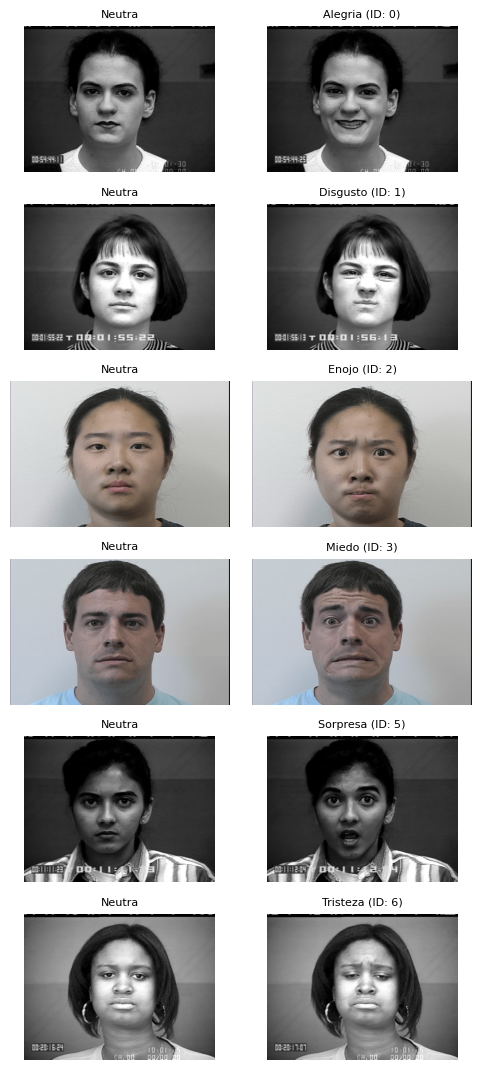

In [5]:
# Uso
test_data = CKPlusCustomLabeledDataset(root_dir=output_path)

# Reporte
counts = Counter(test_data.labels)
idx_to_class = {v: k for k, v in test_data.class_to_idx.items()}

print(f"{'ID':<4} | {'Etiqueta':<12} | {'Cantidad'}")
print("-" * 30)

for idx in sorted(idx_to_class.keys()):
    label_name = idx_to_class[idx]
    cantidad = counts.get(idx, 0)
    print(f"{idx:<4} | {label_name.capitalize():<12} | {cantidad}")

print("-" * 30)
print(f"Total de imágenes: {len(test_data)}")

# Imagenes de muestra
EJEMPLARES_POR_EMOCION = 1  # Cuántos actores distintos por emoción

idx_to_class = {v: k for k, v in test_data.class_to_idx.items()}
id_neutra = test_data.class_to_idx['neutra']
emociones_objetivo = [id for id in idx_to_class.keys() if id != id_neutra]

indices_emociones = list(range(1, len(test_data), 2))
random.shuffle(indices_emociones)

pares_encontrados = {id: [] for id in emociones_objetivo}

for i in indices_emociones:
    _, label_idx = test_data[i]
    
    if label_idx in emociones_objetivo and len(pares_encontrados[label_idx]) < EJEMPLARES_POR_EMOCION:
        img_emocion_tensor, _ = test_data[i]
        img_neutral_tensor, label_neutral = test_data[i-1]
        
        if label_neutral == id_neutra:
            pares_encontrados[label_idx].append((img_neutral_tensor, img_emocion_tensor))
            
    if all(len(lista) == EJEMPLARES_POR_EMOCION for lista in pares_encontrados.values()):
        break

num_emociones = len(emociones_objetivo)
total_filas = num_emociones * EJEMPLARES_POR_EMOCION
fig, axes = plt.subplots(nrows=total_filas, ncols=2, figsize=(5, 1.8 * total_filas))

fila_actual = 0
for id_emocion in sorted(emociones_objetivo):
    nombre_emocion = idx_to_class[id_emocion].capitalize()
    
    for i in range(len(pares_encontrados[id_emocion])):
        img_neutral, img_emocion = pares_encontrados[id_emocion][i]
        
        axes[fila_actual, 0].imshow(img_neutral, cmap='gray')
        axes[fila_actual, 0].set_title("Neutra", fontsize=8)
        axes[fila_actual, 0].axis('off')
        
        axes[fila_actual, 1].imshow(img_emocion, cmap='gray')
        axes[fila_actual, 1].set_title(f"{nombre_emocion} (ID: {id_emocion})", fontsize=8)
        axes[fila_actual, 1].axis('off')
        
        fila_actual += 1

plt.tight_layout()
plt.show()


### Carga Modelo de Detección YOLO

Se utiliza un modelo YOLOv8 ajustado (fine-tuned) para detección de rostros disponible en Hugging Face :   
https://huggingface.co/arnabdhar/YOLOv8-Face-Detection     


In [6]:
# Descarga el modelo si no existe

carpeta_destino_yolo = os.path.join("models", "yolo")

face_model_path = hf_hub_download(
    repo_id='arnabdhar/YOLOv8-Face-Detection',
    filename='model.pt',
    local_dir=carpeta_destino_yolo
)

# Instancia el modelo

yolo_face = YOLO(os.path.join(carpeta_destino_yolo, "model.pt"))

# Info del modelo

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
modelo = yolo_face.model.to(device)
modelo.eval()

# 1 Batch, 3 Canales (RGB, 640 x 640 tamaño de imagen de yolo
input_shape = (1, 3, 640, 640) 

# Generar e imprimir el resumen de la arquitectura
print("Generando resumen del modelo...")
summary(
    modelo,
    input_size=input_shape,
    device=device
)

Generando resumen del modelo...


Layer (type:depth-idx)                             Output Shape              Param #
DetectionModel                                     [1, 5, 8400]              --
├─Sequential: 1-1                                  --                        --
│    └─Conv: 2-1                                   [1, 16, 320, 320]         --
│    │    └─Conv2d: 3-1                            [1, 16, 320, 320]         (432)
│    │    └─BatchNorm2d: 3-2                       [1, 16, 320, 320]         (32)
│    └─Detect: 2-96                                --                        (recursive)
│    │    └─ModuleList: 3-118                      --                        (recursive)
│    └─Conv: 2-3                                   [1, 32, 160, 160]         --
│    │    └─Conv2d: 3-4                            [1, 32, 160, 160]         (4,608)
│    │    └─BatchNorm2d: 3-5                       [1, 32, 160, 160]         (64)
│    └─Detect: 2-96                                --                        (recursi

In [7]:
# Funcion para obtener recortes de caras detectadas
# Obtiene recortes cuadrados. 
# Permite ajustar escala y offset vertical de ser necesario
# Devuelve los recortes junto con el bounding box respecto a la imagen original

def detect_faces_yolo(frame, yolo_model, escala=1, offset_y=0.0):

    results = yolo_model(frame, verbose=False)
    crops = []

    for result in results:
        boxes = result.boxes
        if boxes is None or len(boxes) == 0:
            continue

        xyxy = boxes.xyxy.cpu().numpy()
        areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
        sorted_idx = np.argsort(areas)[::-1]

        for idx in sorted_idx:
            x1, y1, x2, y2 = map(int, xyxy[idx])
            
            w = x2 - x1
            h = y2 - y1
            
            # Centro original
            cx = x1 + w // 2
            cy_original = y1 + h // 2
            
            # Suma un porcentaje de 'h' para mover el centro hacia abajo (menos frente)
            cy = cy_original + int(h * offset_y)
            
            # Aplica escala al lado mayor
            lado = int(max(w, h) * escala)
            
            # Nuevas coordenadas cuadradas con el centro desplazado
            new_x1 = cx - lado // 2
            new_y1 = cy - lado // 2
            new_x2 = cx + lado // 2
            new_y2 = cy + lado // 2
            
            # Límites de la imagen
            new_x1 = max(0, new_x1)
            new_y1 = max(0, new_y1)
            new_x2 = min(frame.shape[1], new_x2)
            new_y2 = min(frame.shape[0], new_y2)
            
            crop = frame[new_y1:new_y2, new_x1:new_x2]
            if crop.size > 0:
                crops.append({
                    'imagen': crop,
                    'bbox': (new_x1, new_y1, new_x2, new_y2)
                })

    return crops

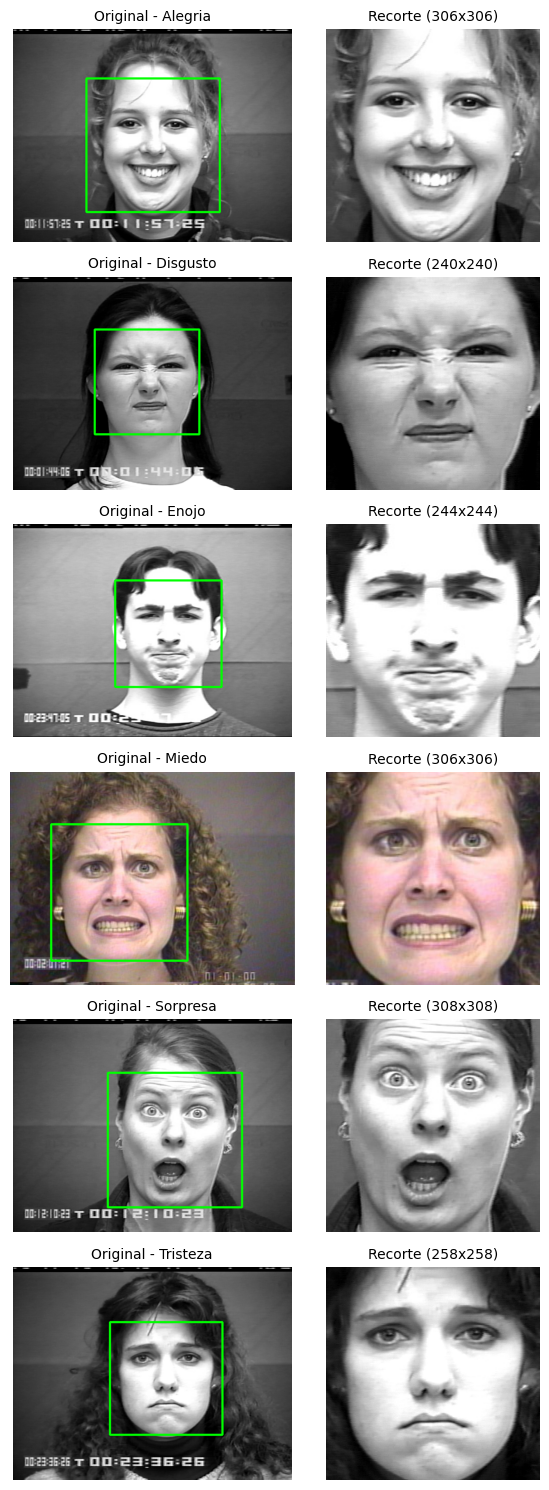

In [8]:
# Ejemplos

idx_to_class = {v: k for k, v in test_data.class_to_idx.items()}
id_neutra = test_data.class_to_idx['neutra']

emociones_objetivo = [id for id in idx_to_class.keys() if id != id_neutra]

EJEMPLARES_POR_EMOCION = 1 
ejemplos_encontrados = {id: [] for id in emociones_objetivo}

# Mezcla los índices para ver imágenes diferentes cada vez que ejecuta
indices = list(range(len(test_data)))
random.shuffle(indices)

# Busca imágenes y genera recortes
for i in indices:
    img_pil, label_idx = test_data[i]
    
    if label_idx in emociones_objetivo and len(ejemplos_encontrados[label_idx]) < EJEMPLARES_POR_EMOCION:
        
        frame = np.array(img_pil)
        
        # Ahora la función nos devuelve una lista de diccionarios
        resultados = detect_faces_yolo(frame, yolo_face, escala=0.9, offset_y=0.05)
        
        if len(resultados) > 0:
            # Extraemos el recorte y las coordenadas del primer rostro detectado
            crop_img = resultados[0]['imagen']
            x1, y1, x2, y2 = resultados[0]['bbox']
            
            # Hacemos una copia para no alterar el array original por si se reusa
            frame_con_caja = frame.copy()
            
            # Dibujamos el rectángulo verde. 
            # Como el array viene de PIL (.convert('RGB')), el color es (R, G, B) -> Verde = (0, 255, 0)
            grosor = 3
            cv2.rectangle(frame_con_caja, (x1, y1), (x2, y2), (0, 255, 0), grosor)
            
            ejemplos_encontrados[label_idx].append((frame_con_caja, crop_img))
            
    if all(len(lista) == EJEMPLARES_POR_EMOCION for lista in ejemplos_encontrados.values()):
        break

# Grafica los resultados
num_emociones = len(emociones_objetivo)
total_filas = num_emociones * EJEMPLARES_POR_EMOCION

fig, axes = plt.subplots(nrows=total_filas, ncols=2, figsize=(6, 2.5 * total_filas))

fila_actual = 0
for id_emocion in sorted(emociones_objetivo):
    nombre_emocion = idx_to_class[id_emocion].capitalize()
    
    for i in range(len(ejemplos_encontrados[id_emocion])):
        img_original_caja, img_crop = ejemplos_encontrados[id_emocion][i]
        
        # 1. Extraemos las dimensiones dinámicamente
        # .shape devuelve (alto, ancho, canales), nos quedamos con los dos primeros
        alto, ancho = img_crop.shape[:2] 
        
        # Columna 1: Imagen Original con Bounding Box
        axes[fila_actual, 0].imshow(img_original_caja)
        axes[fila_actual, 0].set_title(f"Original - {nombre_emocion}", fontsize=10)
        axes[fila_actual, 0].axis('off')
        
        # Columna 2: Recorte YOLO con su resolución real
        axes[fila_actual, 1].imshow(img_crop)
        # 2. Agregamos el tamaño al título (formato Ancho x Alto)
        axes[fila_actual, 1].set_title(f"Recorte ({ancho}x{alto})", fontsize=10)
        axes[fila_actual, 1].axis('off')
        
        fila_actual += 1

plt.tight_layout()
plt.show()

### Carga Modelo de Clasificación de Emociones desarrollado en Aprendizaje Automático

In [9]:
# Rutas y URL
url = "https://drive.google.com/uc?id=1E7S_Nyp7DPeIYtwcdN3qcw4VP8tqKsuj"
carpeta_base = "models"
subcarpeta_destino = os.path.join(carpeta_base, "deteccion_ap")
archivo_modelo = os.path.join(subcarpeta_destino, "model.pt")

# Verifica si la subcarpeta de destino ya existe
if os.path.exists(archivo_modelo):
    print(f"✅ El modelo ya se encuentra en '{archivo_modelo}'. No es necesario descargar.")
else:
    # Si no existe, procede con la descarga y extracción
    print("🚀 El modelo no fue encontrado. Iniciando descarga...")
    
    # Crea carpeta si no existe
    os.makedirs(subcarpeta_destino, exist_ok=True)

    # Descarga
    gdown.download(url, archivo_modelo, quiet=False)

    print("✨ Descarga finalizada.")

# Instancia el modleo

clasificacionAp = torch.jit.load(archivo_modelo)

# Info del modelo

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
modelo = clasificacionAp.to(device)
modelo.eval()

# 1 Batch, 1 Canal (GrayScale), 48 x 48 tamaño de imagen
input_shape = (1,1, 48, 48) 

# Genera e imprime el resumen de la arquitectura
print("Generando resumen del modelo...")
summary(
    modelo,
    input_size=input_shape,
    device=device
)

🚀 El modelo no fue encontrado. Iniciando descarga...


Downloading...
From: https://drive.google.com/uc?id=1E7S_Nyp7DPeIYtwcdN3qcw4VP8tqKsuj
To: d:\GDrive\Postgrado IA\Vision Computadora 2\VpCII\models\deteccion_ap\model.pt
100%|██████████| 1.22M/1.22M [00:00<00:00, 10.0MB/s]

✨ Descarga finalizada.
Generando resumen del modelo...


Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      --                        --
├─Sequential: 1-1                        --                        --
│    └─Sequential: 2-1                   --                        --
│    │    └─Conv2d: 3-1                  --                        288
│    │    └─BatchNorm2d: 3-2             --                        64
│    │    └─ReLU: 3-3                    --                        --
│    └─Sequential: 2-2                   --                        --
│    │    └─Conv2d: 3-4                  --                        9,216
│    │    └─BatchNorm2d: 3-5             --                        64
│    │    └─ReLU: 3-6                    --                        --
│    └─MaxPool2d: 2-3                    --                        --
├─Sequential: 1-2                        --                        --
│    └─Sequential: 2-4                   --                        --
│    │    └

### Evaluación del modelo de clasificación de AP 

Iniciando evaluación conjunta (YOLO + Deteccion AP)...


100%|██████████| 618/618 [00:09<00:00, 64.10it/s]



REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

     Alegria     0.8592    0.8841    0.8714        69
    Disgusto     0.2892    0.4068    0.3380        59
       Enojo     0.2000    0.2889    0.2364        45
       Miedo     0.6471    0.4400    0.5238        25
      Neutra     0.9581    0.6667    0.7863       309
    Sorpresa     0.6609    0.9157    0.7677        83
    Tristeza     0.2692    0.5000    0.3500        28

    accuracy                         0.6553       618
   macro avg     0.5548    0.5860    0.5534       618
weighted avg     0.7443    0.6553    0.6801       618

--------------------------------------------------
Total de imágenes en el dataset: 618
Rostros detectados y clasificados: 618 (100.00%)


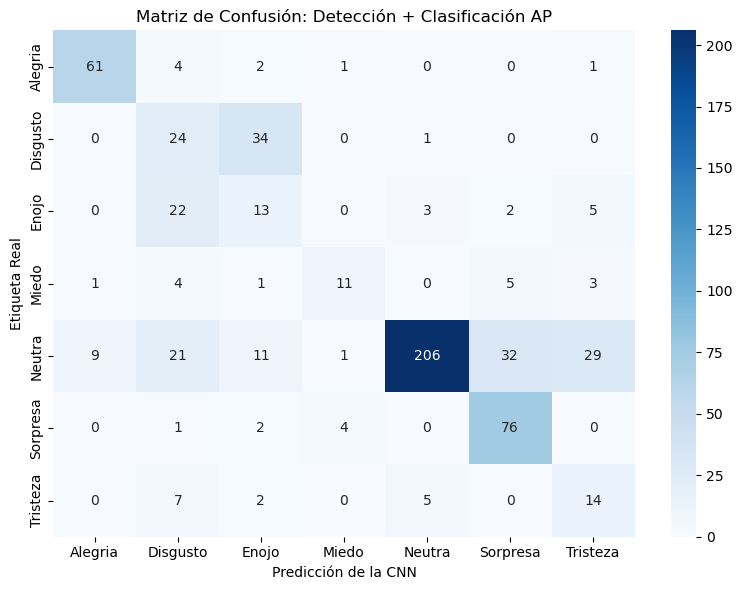

In [10]:
# Preparación de Modelos y Dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Asegura de que el clasificador esté en modo evaluación
clasificacionAp.eval()
clasificacionAp.to(device)

# Define la transformación para el recorte
transformacion_clasificador = T.Compose([
    T.ToPILImage(),         
    T.Grayscale(),
    T.Resize((48, 48)),      
    T.ToTensor(),             
    T.Normalize(mean=[0.5], std=[0.5])
])

# Variables para las métricas
y_true = []
y_pred = []
imagenes_sin_rostro = 0

# Obtiene nombres de las clases ordenados por su ID
idx_to_class = {v: k for k, v in test_data.class_to_idx.items()}
nombres_clases = [idx_to_class[i].capitalize() for i in range(len(idx_to_class))]

print("Iniciando evaluación conjunta (YOLO + Deteccion AP)...")

# Bucle de Evaluación
with torch.no_grad(): # Desactiva el cálculo de gradientes para ahorrar memoria
    # Envuelve el dataset con tqdm para ver el progreso
    for i in tqdm(range(len(test_data))):
        img_pil, true_label = test_data[i]
        
        # YOLO necesita un array de NumPy
        frame = np.array(img_pil)
        
        # Detección con YOLO
        resultados = detect_faces_yolo(frame, yolo_face, escala=1.0, offset_y=0.0)
        
        # Si YOLO detectó al menos una cara
        if len(resultados) > 0:
            # Toma la imagen del primer rostro detectado
            crop_numpy = resultados[0]['imagen']
            
            # Preprocesamiento para la CNN
            # Transformamos y agregamos la dimensión del batch: [C, H, W] -> [1, C, H, W]
            input_tensor = transformacion_clasificador(crop_numpy).unsqueeze(0).to(device)
            
            # Clasificación
            outputs = clasificacionAp(input_tensor)
            _, predicted = torch.max(outputs, 1)
            
            # Guarda los resultados
            y_true.append(true_label)
            y_pred.append(predicted.item())
            
        else:
            # Si YOLO falló en encontrar una cara, registra
            imagenes_sin_rostro += 1

# Imprime el Reporte de Scikit-Learn
print("\n" + "="*50)
print("REPORTE DE CLASIFICACIÓN")
print("="*50)

# Genera el classification_report
reporte = classification_report(
    y_true, 
    y_pred, 
    target_names=nombres_clases,
    digits=4 # Muestra 4 decimales para mayor precisión
)
print(reporte)

# Estadísticas de detección
total_evaluadas = len(test_data)
rostros_procesados = len(y_true)
print("-" * 50)
print(f"Total de imágenes en el dataset: {total_evaluadas}")
print(f"Rostros detectados y clasificados: {rostros_procesados} ({(rostros_procesados/total_evaluadas)*100:.2f}%)")
print("=" * 50)

# Grafica Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title('Matriz de Confusión: Detección + Clasificación AP')
plt.xlabel('Predicción de la CNN')
plt.ylabel('Etiqueta Real')
plt.tight_layout()
plt.show()

### Carga Modelo de Clasificación de Emociones Vision Transformer

Se utiliza un modelo vit-base-patch16-224-in21k ajustado (fine-tuned) para clasificación de emociones:   
https://huggingface.co/dima806/facial_emotions_image_detection     


Toma recortes de 224x224, la corta en parches de 16x16 píxeles, y usa mecanismos de atención para comparar todos los parches entre sí y deducir la expresión facial.

In [11]:
# Descarga (si no existe en caché) e instancia el modelo
# La librería transformers lee automáticamente los pesos y la arquitectura desde el Hub

repo_id = 'dima806/facial_emotions_image_detection'
clasificacionVt = AutoModelForImageClassification.from_pretrained(repo_id)

# Info del modelo (Pasar a GPU y poner en modo evaluación)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
clasificacionVt = clasificacionVt.to(device)
clasificacionVt.eval()

# Tamaño de entrada
# Al ser un modelo ViT (Vision Transformer) base, su tamaño de entrada esperado es 224x224
input_shape = (1, 3, 224, 224) 

# Genera e imprime el resumen de la arquitectura
print("Generando resumen del modelo de emociones...")
summary(
    clasificacionVt,
    input_size=input_shape,
    device=device,
)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Generando resumen del modelo de emociones...


Layer (type:depth-idx)                                  Output Shape              Param #
ViTForImageClassification                               [1, 7]                    --
├─ViTModel: 1-1                                         [1, 197, 768]             --
│    └─ViTEmbeddings: 2-1                               [1, 197, 768]             152,064
│    │    └─ViTPatchEmbeddings: 3-1                     [1, 196, 768]             590,592
│    │    └─Dropout: 3-2                                [1, 197, 768]             --
│    └─ViTEncoder: 2-2                                  [1, 197, 768]             --
│    │    └─ModuleList: 3-3                             --                        85,054,464
│    └─LayerNorm: 2-3                                   [1, 197, 768]             1,536
├─Linear: 1-2                                           [1, 7]                    5,383
Total params: 85,804,039
Trainable params: 85,804,039
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 200.82
I

### Evaluación del modelo de clasificación de VT

Iniciando evaluación conjunta (YOLO + ViT Nativo)...


100%|██████████| 618/618 [00:13<00:00, 46.27it/s]



REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

     Alegria     0.7753    1.0000    0.8734        69
    Disgusto     1.0000    0.6610    0.7959        59
       Enojo     0.4107    0.5111    0.4554        45
       Miedo     0.1250    0.0400    0.0606        25
      Neutra     0.9410    0.8770    0.9079       309
    Sorpresa     0.9176    0.9398    0.9286        83
    Tristeza     0.3019    0.5714    0.3951        28

    accuracy                         0.8042       618
   macro avg     0.6388    0.6572    0.6310       618
weighted avg     0.8244    0.8042    0.8057       618

--------------------------------------------------
Total de imágenes: 618
Procesadas con éxito: 618 (100.00%)


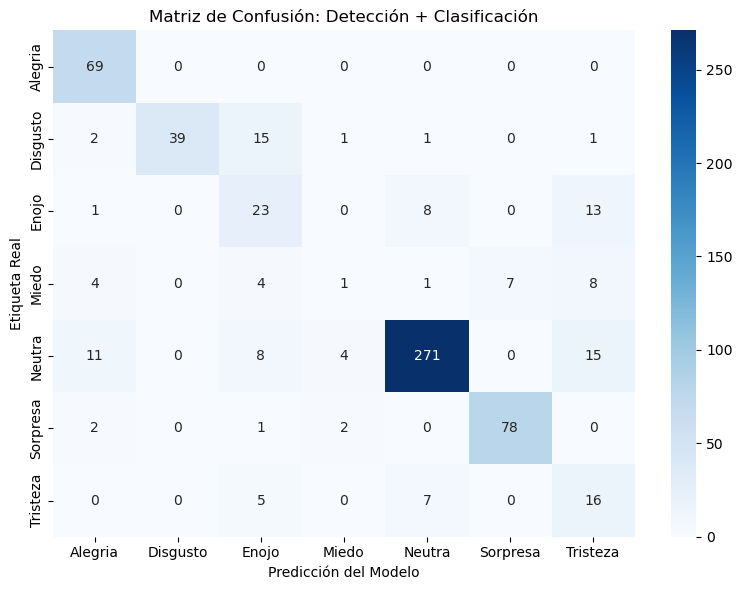

In [12]:
# Preparación de Modelos y Dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Asegura de que el clasificador esté en modo evaluación
clasificacionVt.eval()
clasificacionVt.to(device)

# Define la transformación para el recorte
# Se requieren 3 valores en mean y std porque la imagen es RGB (3 canales)
transformacion_clasificador = T.Compose([
    T.ToPILImage(),         
    T.Resize((224, 224)),      
    T.ToTensor(),             
    T.Normalize(mean=[0.5], std=[0.5])
])

# Diccionario de traducción (del nombre en inglés de Hugging Face a ID)
vit_to_user = {
    'happy': 0,      # alegria
    'disgust': 1,    # disgusto
    'angry': 2,      # enojo
    'fear': 3,       # miedo
    'neutral': 4,    # neutra
    'surprise': 5,   # sorpresa
    'sad': 6         # tristeza
}

# Variables para las métricas
y_true = []
y_pred = []
imagenes_sin_rostro = 0

# Obtiene nombres de las clases ordenados por su ID para el gráfico
idx_to_class = {v: k for k, v in test_data.class_to_idx.items()}
nombres_clases = [idx_to_class[i].capitalize() for i in range(len(idx_to_class))]

print("Iniciando evaluación conjunta (YOLO + ViT Nativo)...")

# 4. Bucle de Evaluación
with torch.no_grad():
    for i in tqdm(range(len(test_data))):
        img_pil, true_label = test_data[i]
        
        frame = np.array(img_pil)
        
        # Detección con YOLO
        resultados = detect_faces_yolo(frame, yolo_face, escala=1.0, offset_y=0.0)
        
        if len(resultados) > 0:
            # Soportamos tanto si YOLO devuelve dict como si devuelve array directo
            recorte = resultados[0]
            crop_numpy = recorte['imagen'] if isinstance(recorte, dict) else recorte
            
            # Preprocesamiento manual para el ViT
            input_tensor = transformacion_clasificador(crop_numpy).unsqueeze(0).to(device)
            
            # Clasificación con ViT
            outputs = clasificacionVt(input_tensor)
            
            # Extrae los logits
            _, predicted_idx = torch.max(outputs.logits, 1)
            
            # Obtiene el nombre de la emoción predicha según la configuración interna del modelo
            nombre_emocion_vit = clasificacionVt.config.id2label[predicted_idx.item()]
            
            # Traduce a ID. Si falla, cae a '4' (neutra)
            pred_user_id = vit_to_user.get(nombre_emocion_vit, 4)
            
            # Guarda
            y_true.append(true_label)
            y_pred.append(pred_user_id)
            
        else:
            imagenes_sin_rostro += 1

# Imprime el Reporte de Scikit-Learn
print("\n" + "="*50)
print("REPORTE DE CLASIFICACIÓN")
print("="*50)

reporte = classification_report(
    y_true, 
    y_pred, 
    target_names=nombres_clases,
    digits=4
)
print(reporte)

# Estadísticas de detección
total_evaluadas = len(test_data)
rostros_procesados = len(y_true)
print("-" * 50)
print(f"Total de imágenes: {total_evaluadas}")
print(f"Procesadas con éxito: {rostros_procesados} ({(rostros_procesados/total_evaluadas)*100:.2f}%)")
print("=" * 50)

# Grafica Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title('Matriz de Confusión: Detección + Clasificación')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Etiqueta Real')
plt.tight_layout()
plt.show()